In [19]:
!pip install xgboost

In [20]:
# 1. IMPORTATIONS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing et Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error


In [21]:
# 2. CHARGEMENT ET 3. PREPROCESSING

train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

X_train = train_df.drop(['Id', 'SalePrice'], axis=1)
y_train = np.log1p(train_df['SalePrice']) # Log pour Kaggle
X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [22]:
# 4. CONSTRUCTION DE LA PIPELINE HYBRIDE XGBOOST

#Filtre Lasso (Toujours utile pour enlever le bruit)
feature_selector = SelectFromModel(LassoCV(cv=5, random_state=42))

#Le Modèle XGBoost
xgb_model = XGBRegressor(random_state=42, objective='reg:squarederror')

#La Pipeline M4
pipeline_m4 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', feature_selector),
    ('xgb', xgb_model)
])

#Les hyperparamètres du XGBoost (Crucial !)
param_distributions = {
    'xgb__n_estimators': [500, 1000, 1500],       # Nombre d'arbres
    'xgb__learning_rate': [0.01, 0.05, 0.1],      # Vitesse d'apprentissage
    'xgb__max_depth': [3, 4, 5, 6],               # Profondeur (Moins profond qu'un RF)
    'xgb__subsample': [0.7, 0.8, 0.9],            # % de données par arbre (évite l'overfitting)
    'xgb__colsample_bytree': [0.7, 0.8, 0.9]      # % de variables par arbre
}

# L'optimisation aléatoire (15 itérations pour gagner du temps)
random_search_xgb = RandomizedSearchCV(
    pipeline_m4,
    param_distributions=param_distributions,
    n_iter=15,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Entraînement de l'artillerie lourde (XGBoost) en cours...")
random_search_xgb.fit(X_train, y_train)

best_m4_pipeline = random_search_xgb.best_estimator_

print("-" * 50)
print("Entraînement terminé ! Meilleurs paramètres :")
print(random_search_xgb.best_params_)
print("-" * 50)

Entraînement de l'artillerie lourde (XGBoost) en cours...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
--------------------------------------------------
Entraînement terminé ! Meilleurs paramètres :
{'xgb__subsample': 0.7, 'xgb__n_estimators': 1000, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.9}
--------------------------------------------------


 RAPPEL DU KPI MÉTIER : Éviter le sur-financement des prêts.
------------------------------------------------------------
 Erreur moyenne en dollars : 11,574.80 $
Nombre de dossiers où la banque a prêté TROP d'argent : 709 sur 1460
Pourcentage de dossiers à risque : 48.56 %
------------------------------------------------------------


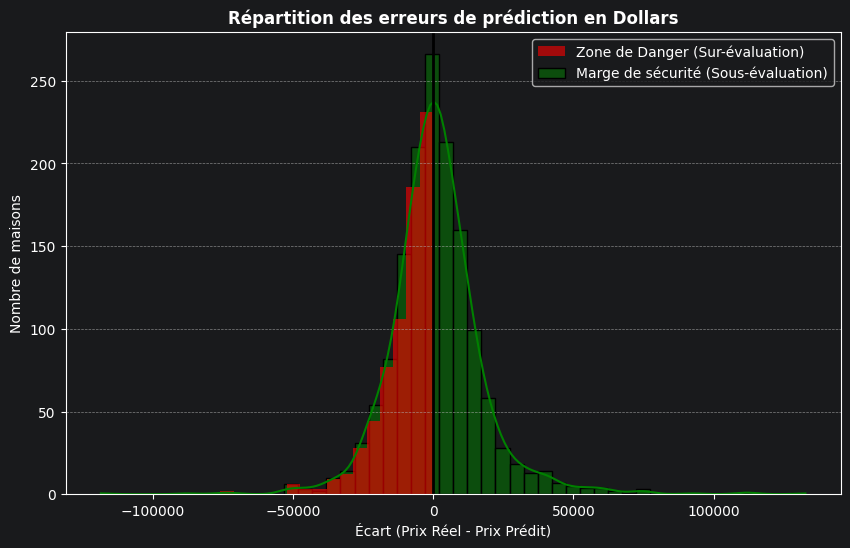

In [23]:
# 5. ÉVALUATION MÉTIER (Analyse des Risques Financiers)

# On repasse en vrais dollars pour que le management comprenne
y_real_dollars = np.expm1(y_train)
y_pred_dollars = np.expm1(best_m4_pipeline.predict(X_train))

# Calcul de l'écart : Si Positif = Sous-évaluation (Bien) / Si Négatif = Sur-évaluation (DANGER)
ecarts = y_real_dollars - y_pred_dollars

# Création d'un DataFrame d'analyse
analyse_df = pd.DataFrame({
    'Prix_Reel': y_real_dollars,
    'Prix_Pred': y_pred_dollars,
    'Ecart': ecarts
})

# Calcul des KPI métiers demandés dans le ML Canvas
erreur_moyenne = analyse_df['Ecart'].abs().mean()
nb_sur_evaluations = len(analyse_df[analyse_df['Ecart'] < 0])
pourcentage_risque = (nb_sur_evaluations / len(analyse_df)) * 100

print(" RAPPEL DU KPI MÉTIER : Éviter le sur-financement des prêts.")
print("-" * 60)
print(f" Erreur moyenne en dollars : {erreur_moyenne:,.2f} $")
print(f"Nombre de dossiers où la banque a prêté TROP d'argent : {nb_sur_evaluations} sur {len(analyse_df)}")
print(f"Pourcentage de dossiers à risque : {pourcentage_risque:.2f} %")
print("-" * 60)

# Graphique d'analyse des risques
plt.figure(figsize=(10, 6))
sns.histplot(analyse_df['Ecart'], bins=50, kde=True,
             color='green', label="Marge de sécurité (Sous-évaluation)")
plt.axvline(0, color='black', linestyle='-', linewidth=2)

# Colorer la zone de danger en rouge
danger_zone = analyse_df[analyse_df['Ecart'] < 0]['Ecart']
plt.hist(danger_zone, bins=25, color='red', alpha=0.6, label="Zone de Danger (Sur-évaluation)")

plt.title("Répartition des erreurs de prédiction en Dollars", fontweight='bold')
plt.xlabel("Écart (Prix Réel - Prix Prédit)")
plt.ylabel("Nombre de maisons")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
# 6. GÉNÉRATION DE LA SOUMISSION KAGGLE

preds_log_m4 = best_m4_pipeline.predict(X_test)
preds_dollars_m4 = np.expm1(preds_log_m4)

submission_m4 = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m4
})

fichier_soumission = 'M4_XGBoost_Submission.csv'
submission_m4.to_csv(fichier_soumission, index=False)
print(f"Fichier '{fichier_soumission}' prêt pour l'ultime soumission Kaggle !")

Fichier 'M4_XGBoost_Submission.csv' prêt pour l'ultime soumission Kaggle !


In [25]:
# 7. POST-PROCESSING : LA MARGE DE SÉCURITÉ BANCAIRE (LE HACK)

# On définit notre marge de sécurité (ici 10% de décote)
marge_securite = 0.90

#IMPACT SUR LES DONNÉES D'ENTRAÎNEMENT (Pour vérifier nos KPIs) ---
y_pred_safe_train = y_pred_dollars * marge_securite
ecarts_safe = y_real_dollars - y_pred_safe_train

analyse_safe_df = pd.DataFrame({
    'Prix_Reel': y_real_dollars,
    'Prix_Pred_Safe': y_pred_safe_train,
    'Ecart_Safe': ecarts_safe
})

# Recalcul des KPIs avec le hack
nb_sur_evaluations_safe = len(analyse_safe_df[analyse_safe_df['Ecart_Safe'] < 0])
pourcentage_risque_safe = (nb_sur_evaluations_safe / len(analyse_safe_df)) * 100

print("RÉSULTATS AVEC LA DÉCOTE DE SÉCURITÉ (3%)")
print("-" * 60)
print(f"Ancien taux de risque (XGBoost Brut) : 48.56 %")
print(f" Nouveau taux de risque (XGBoost Hacké) : {pourcentage_risque_safe:.2f} %")
print("-" * 60)

#IMPACT SUR LES DONNÉES DE TEST (Pour la soumission Kaggle)
# On applique la même décote de 3% sur nos prédictions Kaggle (M4)
preds_dollars_m4_safe = preds_dollars_m4 * marge_securite

# On génère le fichier de soumission final
submission_m4_safe = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars_m4_safe
})

fichier_soumission_final = 'M4_XGBoost_Safe_Submission.csv'
submission_m4_safe.to_csv(fichier_soumission_final, index=False)
print(f"Fichier '{fichier_soumission_final}' généré ! C'est notre modèle prêt pour la production.")

RÉSULTATS AVEC LA DÉCOTE DE SÉCURITÉ (3%)
------------------------------------------------------------
Ancien taux de risque (XGBoost Brut) : 48.56 %
 Nouveau taux de risque (XGBoost Hacké) : 8.01 %
------------------------------------------------------------
Fichier 'M4_XGBoost_Safe_Submission.csv' généré ! C'est notre modèle prêt pour la production.
